<a href="https://colab.research.google.com/github/ANJALICHAMOLI/Standford-dogs-CNN-project-/blob/main/9_Final_conclusion_and_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 9 — Final Comparison**

This notebook brings together every experiment from the entire project
into one place
* one chart
* one table
* one honest conclusion.

The goal was never just to get good accuracy. It was to understand
what actually moves the needle and why, by working through the problem
in layers rather than jumping straight to the answer.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
results = {
    'Scratch CNN\nBaseline':           0.0700,
    'Optuna\nTuned CNN':               0.1453,
    'MobileNetV2\nFE 128×128':         0.7568,
    'MobileNetV2\nFT 128×128':         0.7255,
    'EfficientNetB0\nFE 128×128':      0.7021,
    'NASNetMobile\nFE 128×128':        0.5663,
    'ResNet50\nFE 128×128':            0.5656,
    'MobileNetV2\nFE 224×224':         0.8406,
    'MobileNetV2\nFT 224×224':         0.8100,
}

## **Full Journey — Every Experiment**

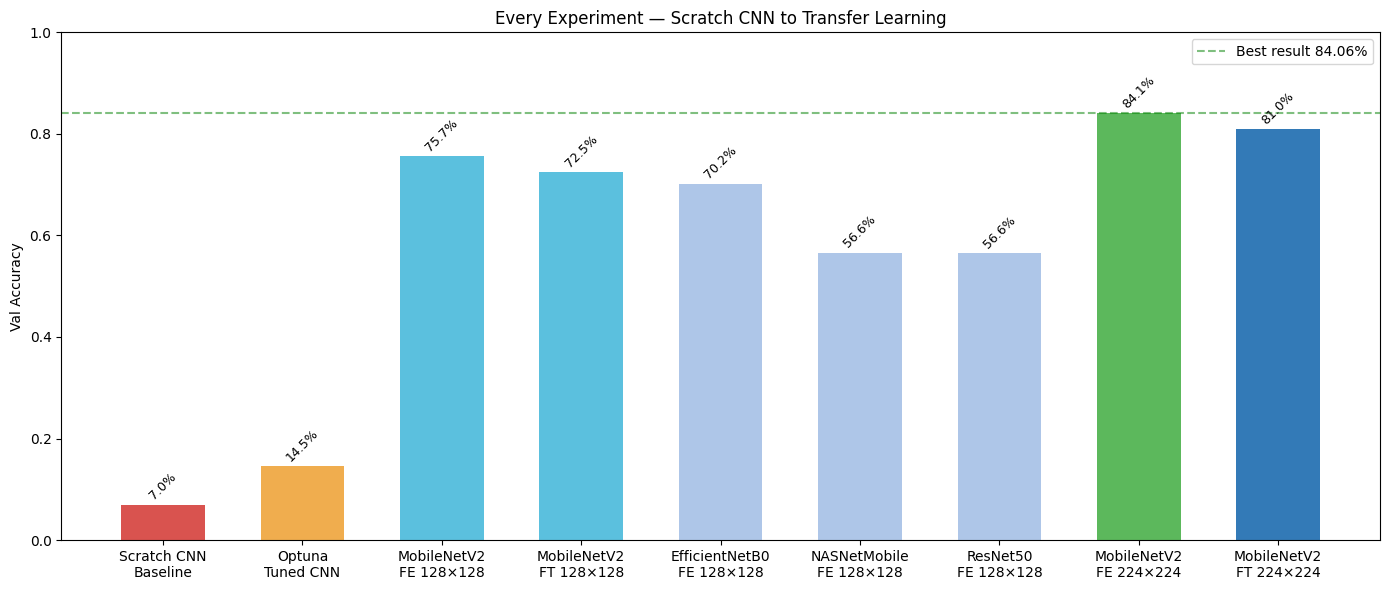

In [ ]:
colors = [
    '#d9534f',  # scratch baseline
    '#f0ad4e',  # optuna
    '#5bc0de',  # mobilenet fe 128
    '#5bc0de',  # mobilenet ft 128
    '#aec6e8',  # efficientnet
    '#aec6e8',  # nasnet
    '#aec6e8',  # resnet
    '#5cb85c',  # mobilenet fe 224
    '#337ab7',  # mobilenet ft 224
]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(results.keys(), results.values(), color=colors, width=0.6)
ax.set_ylabel('Val Accuracy')
ax.set_title('Every Experiment — Scratch CNN to Transfer Learning')
ax.set_ylim(0, 1.0)
ax.axhline(y=0.8406, color='green', linestyle='--', alpha=0.5, label='Best result 84.06%')
ax.legend()

for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', fontsize=9, rotation=45)

plt.tight_layout()
plt.show()

# **Results Table**

In [ ]:
import pandas as pd

table_data = [
    ['1', 'Scratch CNN baseline',          '7.40%',  'Reference point'],
    ['2', 'Optuna tuned scratch CNN',      '14.53%', 'Best hyperparameter search can do'],
    ['3', 'MobileNetV2 FE 128×128',        '75.68%', 'Transfer learning baseline'],
    ['4', 'MobileNetV2 FT 128×128',        '72.55%', 'Fine tuning hurt — overfit base'],
    ['5', 'EfficientNetB0 FE 128×128',     '70.21%', 'Underperformed vs MobileNetV2'],
    ['6', 'NASNetMobile FE 128×128',       '56.63%', 'Weakest lightweight model'],
    ['7', 'ResNet50 FE 128×128',           '56.56%', 'Heavy model, small input = poor fit'],
    ['8', 'MobileNetV2 FE 224×224',        '84.06%', 'Best result — larger input size'],
    ['9', 'MobileNetV2 FT 224×224',        '81.00%', 'Fine tuning still underperformed']
]

df = pd.DataFrame(
    table_data,
    columns=['S.No', 'Approach', 'Val Accuracy', 'Key Insight']
)

styled_df = (
    df.style
    .hide(axis="index")
    .set_caption("Final Model Comparison")
    .set_properties(**{
        'text-align': 'left',
        'padding': '10px'
    })
    .set_table_styles([
        {
            'selector': 'caption',
            'props': [
                ('font-size', '20px'),
                ('font-weight', 'bold'),
                ('text-align', 'center')
            ]
        },
        {
            'selector': 'th',
            'props': [
                ('background-color', '#40466e'),
                ('color', 'white'),
                ('font-weight', 'bold')
            ]
        }
    ])
)

styled_df

S.No,Approach,Val Accuracy,Key Insight
1,Scratch CNN baseline,7.40%,Reference point
2,Optuna tuned scratch CNN,14.53%,Best hyperparameter search can do
3,MobileNetV2 FE 128×128,75.68%,Transfer learning baseline
4,MobileNetV2 FT 128×128,72.55%,Fine tuning hurt — overfit base
5,EfficientNetB0 FE 128×128,70.21%,Underperformed vs MobileNetV2
6,NASNetMobile FE 128×128,56.63%,Weakest lightweight model
7,ResNet50 FE 128×128,56.56%,"Heavy model, small input = poor fit"
8,MobileNetV2 FE 224×224,84.06%,Best result — larger input size
9,MobileNetV2 FT 224×224,81.00%,Fine tuning still underperformed


## **Learning Curve —> How accuracy improved notebook by notebook**

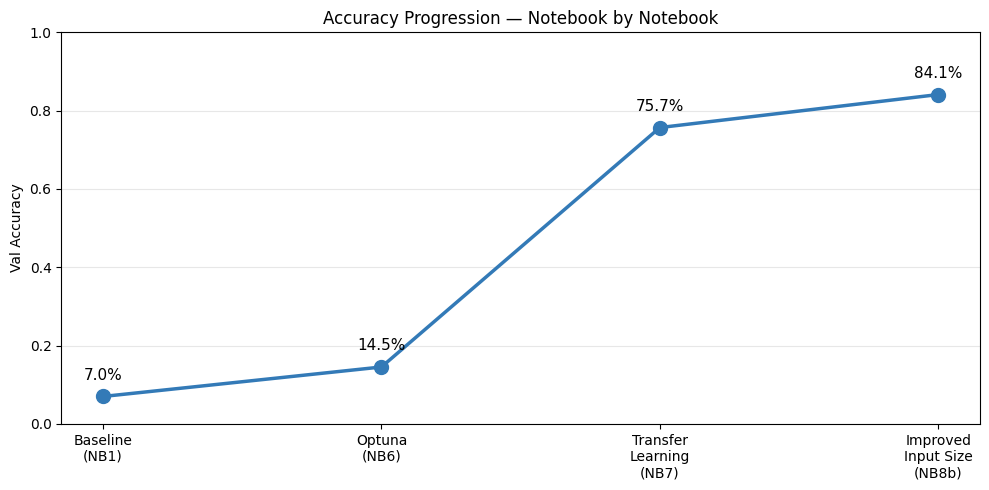

In [ ]:
milestones = [
    'Baseline\n(NB1)',
    'Optuna\n(NB6)',
    'Transfer\nLearning\n(NB7)',
    'Improved\nInput Size\n(NB8b)'
]
milestone_accs = [0.07, 0.1453, 0.7568, 0.8411]

plt.figure(figsize=(10, 5))
plt.plot(milestones, milestone_accs, marker='o', linewidth=2.5,
         markersize=10, color='#337ab7')
for i, (m, a) in enumerate(zip(milestones, milestone_accs)):
    plt.annotate(f'{a:.1%}', (m, a),
                textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=11)
plt.ylabel('Val Accuracy')
plt.title('Accuracy Progression — Notebook by Notebook')
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## **3 Key Conclusions**

### **1. What moved the needle most**

Transfer learning had the greatest impact on performance. While hyperparameter tuning improved the scratch CNN from **7.00%** to **14.53%** validation accuracy, a frozen MobileNetV2 immediately achieved over **75%** accuracy and ultimately reached **84.06%** with 224×224 inputs.

This highlights the value of pretrained representations. Features learned from ImageNet transferred far more effectively to the target dataset than attempting to learn visual representations from scratch.

---

### **2. Lessons from hyperparameter tuning and fine tuning**

Optuna successfully improved the scratch CNN and more than doubled its performance compared to the baseline model. However, the experiments demonstrated that hyperparameter optimization can only search within the architecture provided. When the model architecture itself becomes the bottleneck, tuning alone cannot achieve the same gains as transfer learning.

Fine tuning also produced mixed results. Despite unfreezing additional layers and experimenting with learning-rate scheduling, the best fine-tuning runs did not consistently outperform the strongest feature extraction model. This suggests that the pretrained MobileNetV2 features already generalized well to the dataset and that further adaptation increased the risk of overfitting.

Overall, transfer learning provided substantially larger gains than either manual tuning or automated hyperparameter optimization.

---

### **3. What I'd do differently**

- **Start with 224×224 inputs from the beginning** → Earlier experiments compared 64×64, 128×128, and 224×224 image sizes, but 128×128 was initially chosen due to computational constraints. Later results showed that 224×224 inputs improved validation accuracy by approximately **8 percentage points**, making the additional computation worthwhile.

- **Add data augmentation earlier** → Stronger augmentation would likely improve generalization, reduce overfitting, and potentially make fine tuning more effective.

- **Prioritize transfer learning sooner** → The experiments showed that pretrained architectures contributed far more to performance than extensive tuning of a scratch CNN. Future work would begin with transfer learning and focus optimization efforts there.

---

## **Conclusion**

The strongest model developed in this project was **MobileNetV2 feature extraction with 224×224 inputs**, achieving **84.06% validation accuracy**.

The progression from **7.00%** (scratch CNN baseline) to **84.06%** (MobileNetV2 feature extraction) demonstrates that pretrained feature representations were the single most important contributor to performance. While hyperparameter optimization and fine tuning provided useful insights, the largest gains came from selecting an appropriate architecture and leveraging pretrained knowledge through transfer learning.